In [44]:
import pandas as pd  # Manejo y analisis de datos
import numpy as np  # Calculos numericos

import matplotlib.pyplot as plt  # Crear graficos
import seaborn as sns  # Graficos estadisticos

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler

sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)

In [45]:
ruta = "clientes_pyme_examen.csv"
df = pd.read_csv(ruta)
df.head()

,id_cliente,segmento_pyme,volumen_envios_mes,gasto_mensual,fecha_ultimo_despacho,fecha_ultima_entrega,dias_retraso_promedio,target_fuga
0,C-2001,Pyme-C,68,892.54,2026-01-08,2026-01-09,0.6,0
1,C-2002,Pyme-C,66,3303.79,2026-01-03,2026-01-07,1.8,0
2,C-2003,Pyme-B,48,910.25,2026-01-17,2026-01-20,0.4,0
3,C-2004,Pyme-A,183,1535.70,2026-01-18,2026-01-21,1.3,0
4,C-2005,Pyme-A,154,2980.28,2026-01-01,2026-01-03,1.6,0


In [46]:
df.shape

(1200, 8)

In [47]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 8 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   id_cliente             1200 non-null   str    
 1   segmento_pyme          1200 non-null   str    
 2   volumen_envios_mes     1200 non-null   int64  
 3   gasto_mensual          1200 non-null   float64
 4   fecha_ultimo_despacho  1200 non-null   str    
 5   fecha_ultima_entrega   1097 non-null   str    
 6   dias_retraso_promedio  1097 non-null   float64
 7   target_fuga            1200 non-null   int64  
dtypes: float64(2), int64(2), str(4)
memory usage: 75.1 KB


El dataset contiene 1.200 registros y 8 variables. Inicialmente, las fechas se encuentran almacenadas como texto, por lo que será necesario convertirlas antes de validar su consistencia.

In [48]:
df.duplicated(subset=["id_cliente"]).sum()

np.int64(0)

In [49]:
df["id_cliente"].nunique()

1200

Se revisaron los registros duplicados y la unicidad del identificador del cliente. Esta validación permite detectar clientes repetidos antes de realizar el modelado

In [50]:
columnas_fecha = ["fecha_ultimo_despacho","fecha_ultima_entrega"]
for col in columnas_fecha:
    df[col] = pd.to_datetime(df[col],errors="coerce")

In [51]:
df[columnas_fecha].dtypes

fecha_ultimo_despacho    datetime64[us]
fecha_ultima_entrega     datetime64[us]
dtype: object

Las variables de fecha se convierten a formato datetime. Se utiliza errors="coerce" para transformar en NaT cualquier valor que no pueda interpretarse correctamente.

In [52]:
df.isnull().mean().round(4)*100

id_cliente               0.00
segmento_pyme            0.00
volumen_envios_mes       0.00
gasto_mensual            0.00
fecha_ultimo_despacho    0.00
fecha_ultima_entrega     8.58
dias_retraso_promedio    8.58
target_fuga              0.00
dtype: float64

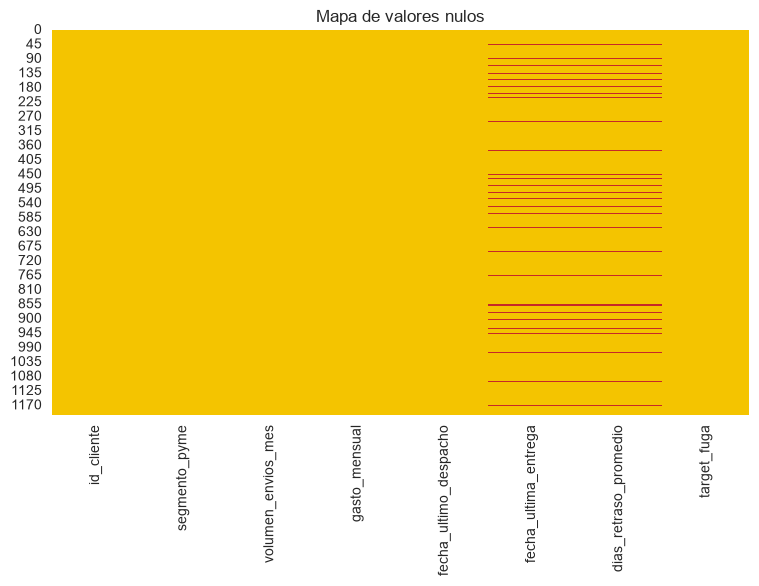

In [53]:
plt.figure(figsize=(9, 5))

sns.heatmap(df.isnull(), cbar=False, cmap=["#F4C400", "#C62828"])
plt.title("Mapa de valores nulos")
plt.show()

Los valores nulos se concentran en la fecha de última entrega y en los días promedio de retraso. Antes de imputarlos, se debe revisar si su ausencia está relacionada con alguna inconsistencia logística o con la variable objetivo.

In [54]:
#Descripcion de las variables numericas:
variables_numericas = ["volumen_envios_mes","gasto_mensual", "dias_retraso_promedio"]
df[variables_numericas].describe()

,volumen_envios_mes,gasto_mensual,dias_retraso_promedio
count,1200.000000,1200.000000,1097.000000
mean,141.915833,8956.235233,0.837010
std,64.457966,24372.299227,1.593141
min,2.000000,-147.820000,-4.000000
25%,89.000000,1588.640000,0.400000
50%,145.000000,2670.945000,0.900000
75%,196.000000,3713.520000,1.500000
max,250.000000,99999.000000,10.000000


La descripción permite identificar valores que se alejan del comportamiento esperado. En particular, se observan gastos iguales a 99999, valores negativos de gasto y retrasos negativos

In [55]:
#Registros con gasto_mensual = 99999
print("Registros con gasto igual a 99999:", df[df["gasto_mensual"] == 99999].shape[0])
df[df["gasto_mensual"] == 99999].head(5)

Registros con gasto igual a 99999: 80


,id_cliente,segmento_pyme,volumen_envios_mes,gasto_mensual,fecha_ultimo_despacho,fecha_ultima_entrega,dias_retraso_promedio,target_fuga
14,C-2015,Pyme-C,123,99999.0,2026-01-08,NaT,NaN,0
29,C-2030,Pyme-C,164,99999.0,2026-01-18,NaT,NaN,0
44,C-2045,Pyme-A,82,99999.0,2026-01-28,NaT,NaN,0
59,C-2060,Pyme-C,249,99999.0,2026-01-04,2026-01-03,-3.0,0
74,C-2075,Pyme-C,89,99999.0,2026-01-03,NaT,NaN,0


El valor 99999 no representa un gasto real, sino un codigo utilizado en el sistema de origen. Por esta razon, debe tratarse como un valor faltante y no como un valor atipico valido.

In [56]:
#Gastos negativos
print("Registros con gasto negativo:", df[df["gasto_mensual"] < 0].shape[0])
df[df["gasto_mensual"] < 0].head(5)

Registros con gasto negativo: 51


,id_cliente,segmento_pyme,volumen_envios_mes,gasto_mensual,fecha_ultimo_despacho,fecha_ultima_entrega,dias_retraso_promedio,target_fuga
21,C-2022,Pyme-B,137,-75.14,2026-01-18,NaT,NaN,0
43,C-2044,Pyme-A,52,-51.48,2026-01-03,NaT,NaN,0
65,C-2066,Pyme-C,42,-119.10,2026-01-05,NaT,NaN,0
87,C-2088,Pyme-B,212,-140.12,2026-01-26,NaT,NaN,0
109,C-2110,Pyme-A,140,-58.39,2026-01-14,NaT,NaN,0


Los gastos negativos corresponden a notas credito de fletes mal procesadas. Debido a que no representan correctamente el gasto mensual del cliente, se consideran valores invalidos.

In [57]:
gasto_negativo = df["gasto_mensual"] < 0
df.loc[gasto_negativo, "gasto_mensual"].head()


21     -75.14
43     -51.48
65    -119.10
87    -140.12
109    -58.39
Name: gasto_mensual, dtype: float64

Convertir estos valores mediante valor absoluto cambiaria una inconsistencia en un gasto aparentemente valido, sin tener evidencia de que ese sea el valor correcto

In [58]:
retraso_negativo = df["dias_retraso_promedio"] < 0
print("Registros con retraso negativo:", retraso_negativo.sum())
df.loc[retraso_negativo,["fecha_ultimo_despacho","fecha_ultima_entrega","dias_retraso_promedio"]].head()

Registros con retraso negativo: 100


,fecha_ultimo_despacho,fecha_ultima_entrega,dias_retraso_promedio
11,2026-01-09,2026-01-06,-1.0
23,2026-01-15,2026-01-14,-3.0
35,2026-01-03,2026-01-02,-3.0
47,2026-01-07,2026-01-06,-1.0
59,2026-01-04,2026-01-03,-3.0


Un retraso negativo indica una inconsistencia en las fechas logisticas. Aplicar abs() no es adecuado porque convertiria el error en un retraso positivo. Se decide convertir estos registros en valores nulos para imputarlos posteriormente

In [59]:
#validacion de fechas inconsistentes
fechas_inconsistentes = (df["fecha_ultima_entrega"] <df["fecha_ultimo_despacho"])
print("Entregas anteriores al despacho:",fechas_inconsistentes.sum())

Entregas anteriores al despacho: 100


In [60]:
df.loc[fechas_inconsistentes,["id_cliente", "fecha_ultimo_despacho","fecha_ultima_entrega","dias_retraso_promedio"]].head()

,id_cliente,fecha_ultimo_despacho,fecha_ultima_entrega,dias_retraso_promedio
11,C-2012,2026-01-09,2026-01-06,-1.0
23,C-2024,2026-01-15,2026-01-14,-3.0
35,C-2036,2026-01-03,2026-01-02,-3.0
47,C-2048,2026-01-07,2026-01-06,-1.0
59,C-2060,2026-01-04,2026-01-03,-3.0


Se encontraron registros cuya fecha de entrega es anterior a la fecha de despacho. Esto confirma que los retrasos negativos corresponden a inconsistencias en las fechas y no a valores logisticos validos

In [79]:
df["target_fuga"].value_counts()

target_fuga
0    1158
1      42
Name: count, dtype: int64

In [61]:
df["target_fuga"].value_counts(normalize=True).round(4) * 100

target_fuga
0    96.5
1     3.5
Name: proportion, dtype: float64

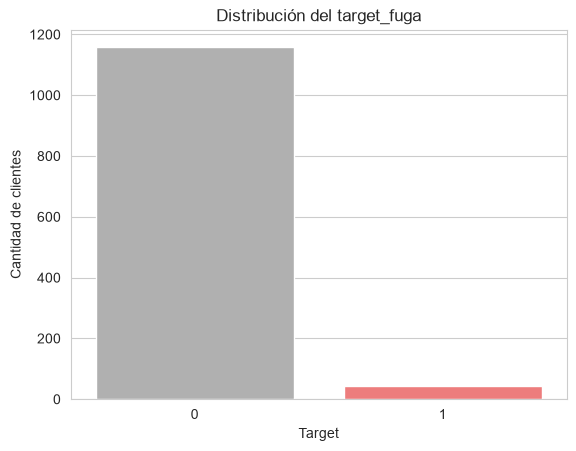

In [62]:
sns.countplot(data=df,x="target_fuga",hue="target_fuga",palette={0: "#B0B0B0", 1: "#FF6B6B"},legend=False)
plt.title("Distribución del target_fuga")
plt.xlabel("Target")
plt.ylabel("Cantidad de clientes")
plt.show()

La variable objetivo presenta un desbalance importante, dado que los clientes con target = 1 representan una proporcion pequeña de la muestra. Por esta razon, la division entre entrenamiento y prueba se realizara de forma estratificada para conservar la distribucion de las clases. Adicionalmente, se debe evaluar tecnicas de balanceo como ponderacion de clases y SMOTE. Estas tecnicas se aplican unicamente sobre los datos de entrenamiento y dentro del proceso de validacion cruzada, evitando modificar la distribucion real del conjunto de prueba y reduciendo el riesgo de fuga de datos.

In [63]:
#Revisar si las anomalias estan relacionadas con el target
df["gasto_99999"] = (df["gasto_mensual"] == 99999).astype(int)
df["gasto_negativo"] = (df["gasto_mensual"] < 0).astype(int)
df["retraso_negativo"] = (df["dias_retraso_promedio"] < 0).astype(int)
df["retraso_nulo"] = (df["dias_retraso_promedio"].isnull()).astype(int)

In [64]:
indicadores = ["gasto_99999","gasto_negativo","retraso_negativo","retraso_nulo"]
for col in indicadores:
    resultado = (df.groupby(col)["target_fuga"].agg(["mean", "count"]))
    resultado["tasa_target_%"] = (resultado["mean"] * 100).round(2)

    print(f"{col}")
    print(resultado)

gasto_99999
                 mean  count  tasa_target_%
gasto_99999                                
0            0.035714   1120           3.57
1            0.025000     80           2.50
gasto_negativo
                    mean  count  tasa_target_%
gasto_negativo                                
0               0.033943   1149           3.39
1               0.058824     51           5.88
retraso_negativo
                      mean  count  tasa_target_%
retraso_negativo                                
0                 0.025455   1100           2.55
1                 0.140000    100          14.00
retraso_nulo
                  mean  count  tasa_target_%
retraso_nulo                                
0             0.036463   1097           3.65
1             0.019417    103           1.94


Esta comparacion permite determinar si la presencia de una anomalia contiene informacion relacionada con el target. Sin embargo, una relacion observada no implica que el valor incorrecto deba conservarse sin tratamiento

In [65]:
#Aplicar las correcciones
df_clean = df.copy()

# El 99999 es un codigo, no un gasto real
df_clean.loc[df_clean["gasto_mensual"] == 99999,"gasto_mensual"] = np.nan

# Los gastos negativos son inconsistencias
df_clean.loc[df_clean["gasto_mensual"] < 0,"gasto_mensual"] = np.nan

# Los retrasos negativos no son validos
df_clean.loc[df_clean["dias_retraso_promedio"] < 0,"dias_retraso_promedio"] = np.nan

In [66]:
df_clean[["gasto_mensual","dias_retraso_promedio"]].isnull().mean().round(4) * 100

gasto_mensual            10.92
dias_retraso_promedio    16.92
dtype: float64

Estas correcciones pueden realizarse antes de dividir los datos porque corresponden a reglas conocidas del negocio y no requieren calcular estadisticas de la muestra. La imputacion todavia no se realiza.

In [67]:
#Definir features y target
features = ["gasto_mensual","dias_retraso_promedio"]
X = df_clean[features]
y = df_clean["target_fuga"].astype(int)

In [68]:
#Dividir entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.30, stratify=y,random_state=42)

In [69]:
print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (840, 2)
Test: (360, 2)


In [70]:
print("distribucion train:")
print(y_train.value_counts(normalize=True).round(4))

print("distribucion test:")
print(y_test.value_counts(normalize=True).round(4))

distribucion train:
target_fuga
0    0.9655
1    0.0345
Name: proportion, dtype: float64
distribucion test:
target_fuga
0    0.9639
1    0.0361
Name: proportion, dtype: float64


La división se realiza antes de imputar y escalar. Se utiliza stratify=y para conservar una proporción similar de clientes de cada clase y random_state=42 para obtener resultados reproducibles.

In [71]:
print("Nulos en train:")
print(X_train.isnull().mean().round(4) * 100)

print("Nulos en test:")
print(X_test.isnull().mean().round(4) * 100)

Nulos en train:
gasto_mensual            11.43
dias_retraso_promedio    17.50
dtype: float64
Nulos en test:
gasto_mensual             9.72
dias_retraso_promedio    15.56
dtype: float64


Es normal que tanto entrenamiento como prueba contengan valores nulos. Estos serán transformados por el mismo pipeline, pero los valores utilizados para imputar se calcularán unicamente con entrenamiento.

In [72]:
#pipeline de procesamiento
preprocesamiento = Pipeline([
    ("imputacion",
        SimpleImputer(strategy="median")),
    ("escalado",
     RobustScaler()
    )])

La mediana se selecciona porque presenta mayor resistencia a valores atipicos y distribuciones asimetricas. Se utiliza RobustScaler porque escala con base en la mediana y el rango intercuartilico.

In [73]:
X_train_transformado = preprocesamiento.fit_transform(X_train)
X_test_transformado = preprocesamiento.transform(X_test)

fit_transform() se utiliza unicamente con X_train. Para X_test se utiliza transform(), de modo que la mediana y los parametros de escalado provienen exclusivamente del conjunto de entrenamiento.

In [74]:
#Revisar la mediana aprendida
medianas_train = (preprocesamiento.named_steps["imputacion"].statistics_)

pd.DataFrame({
    "variable": features,
    "mediana_train": medianas_train})

,variable,mediana_train
0,gasto_mensual,2619.39
1,dias_retraso_promedio,1.10


Esto demuestra que el pipeline conserva las medianas aprendidas con entrenamiento.

In [75]:
#Validar el resultado
print("Nulos en train transformado:", np.isnan(X_train_transformado).sum())
print("Nulos en test transformado:",np.isnan(X_test_transformado).sum())

Nulos en train transformado: 0
Nulos en test transformado: 0


In [76]:
print("Shape train:", X_train_transformado.shape)
print("Shape test:", X_test_transformado.shape)

Shape train: (840, 2)
Shape test: (360, 2)


In [77]:
from preparar_features_clientes import preparar_features_clientes

resultado = preparar_features_clientes(df)
(X_train_transformado, X_test_transformado,y_train,y_test,preprocesamiento) = resultado

In [78]:
print("Train:", X_train_transformado.shape)
print("Test:", X_test_transformado.shape)
print("Nulos train:", np.isnan(X_train_transformado).sum())
print("Nulos test:", np.isnan(X_test_transformado).sum())

Train: (840, 2)
Test: (360, 2)
Nulos train: 0
Nulos test: 0


La revision permitio identificar codigos de origen, gastos negativos, retrasos negativos, valores nulos, inconsistencias entre fechas y desbalance en la variable objetivo. Los valores invalidos se transformaron en nulos mediante reglas de negocio. Posteriormente, los datos se dividieron de forma estratificada y la imputacion por mediana y el escalado robusto se ajustaron unicamente con el conjunto de entrenamiento. De esta manera se evita utilizar informacion del conjunto de prueba durante la preparacion de las variables y se reduce el riesgo de fuga de datos.